# **CONCLUÍDO**

## <font color = 56A5EC>**Inicialização**

### <font color = FFB90F>**Instalações**

In [2]:
%pip install scikit-survival --quiet
%pip install seaborn --quiet
%pip install --upgrade lifelines --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### <font color = FFB90F>**Importações**

In [3]:
%pip install scikit-survival --quiet

# === Visualização ===
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# === Manipulação de Dados ===
import numpy as np
import pandas as pd

# === Scikit-learn ===
# Pré-Processamento
from sklearn import set_config
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score)
from sksurv.metrics import integrated_brier_score, concordance_index_ipcw
from sksurv.util import Surv
set_config(display = "text")

# === Lifelines ===
# Modelagem e Estimações
from lifelines import CoxPHFitter, KaplanMeierFitter,       NelsonAalenFitter
from lifelines.statistics import proportional_hazard_test, multivariate_logrank_test
from lifelines.calibration import survival_probability_calibration

Note: you may need to restart the kernel to use updated packages.


## <font color = 56A5EC>**Tratamento dos Dados**

### <font color = FFB90F>**Preparação dos Dados**

In [4]:
def data_preparing(df):
    """
    Descrição:
      Prepara o conjunto de dados para análise, aplicando filtros e transformações.

    Parâmetros:
      df: pandas.DataFrame
        O conjunto de dados que será preparado.

    Retorno:
      pandas.DataFrame
        O conjunto de dados após as transformações.
    """

    # Cópia do DataFrame original
    df_aux = df.copy()

    # Redefinição dos índices
    df_aux = df_aux.reset_index(drop = True)

    # ============================ #
    # === SELEÇÕES NAS COLUNAS === #
    # ============================ #

    # Seleção 1 - Topografia Colorretal (C18, C19, C20)
    df_aux = df_aux[df_aux.TOPOGRUP.isin(['C18', 'C19', 'C20'])]

    # Seleção 2 - Residentes de SP
    df_aux = df_aux[df_aux.UFRESID == 'SP']

    # Seleção 3 - Casos com confirmação microscópica
    df_aux = df_aux[df_aux.BASEDIAG == 3]

    # Seleção 4 - ECGRUP's = I, II, III, IV
    df_aux = df_aux[df_aux.ECGRUP.isin(['I', 'II', 'III', 'IV'])]

    # Seleção 5 - ANODIAG até 2019
    df_aux = df_aux[df_aux.ANODIAG <= 2019]

    # Seleção 6 - IDADE maior que 19
    df_aux = df_aux[df_aux.IDADE > 19]

    # Seleção 7 – CATEATEND com grupos SUS e SEM INFORMAÇÃO
    df_aux = df_aux[df_aux.CATEATEND.isin([2, 9])]

    # ========================== #
    # === AJUSTE DAS COLUNAS === #
    # ========================== #

    # Ajuste 1 - Número da DRS
    drs_num = df_aux["DRS"].astype(str).str.extract(r"(\d+)")[0]
    df_aux["nDRS"] = pd.to_numeric(drs_num, errors = "coerce")
    df_aux = df_aux[df_aux["nDRS"].notna()]
    df_aux["nDRS"] = df_aux["nDRS"].astype(int)


    # Ajuste 2 - Recalcular Variáveis
    ## Ajuste 2.1 - Colunas de data para o formato datetime
    list_datas = ['DTCONSULT', 'DTDIAG', 'DTTRAT', 'DTULTINFO']
    for col_data in list_datas:
        df_aux[col_data] = pd.to_datetime(df_aux[col_data], errors = "coerce")

    ## Ajuste 2.2 - Calcular a diferença entre as datas para criar novas variáveis
    df_aux['CONSDIAG'] = (df_aux.DTDIAG    - df_aux.DTCONSULT).dt.days
    df_aux['TRATCONS'] = (df_aux.DTTRAT    - df_aux.DTCONSULT).dt.days
    df_aux['DIAGTRAT'] = (df_aux.DTTRAT    - df_aux.DTDIAG).dt.days
    df_aux['ULTIDIAG'] = (df_aux.DTULTINFO - df_aux.DTDIAG).dt.days

    ## Ajuste 2.3 - Preencher os valores NaN com -1
    df_aux.fillna({'CONSDIAG': -1, 'TRATCONS': -1, 'DIAGTRAT': -1}, inplace = True)

    ## Ajuste 2.4 - Implementar a categorização das variáveis calculadas
    df_aux['CONSDIAG_CAT'] = [3 if consdiag < 0 else 0 if consdiag <= 30 else 1 if consdiag <= 60 else 2 for consdiag in df_aux.CONSDIAG]
    df_aux['TRATCONS_CAT'] = [3 if tratcons < 0 else 0 if tratcons <= 60 else 1 if tratcons <= 90 else 2 for tratcons in df_aux.TRATCONS]
    df_aux['DIAGTRAT_CAT'] = [3 if diagtrat < 0 else 0 if diagtrat <= 60 else 1 if diagtrat <= 90 else 2 for diagtrat in df_aux.DIAGTRAT]


    # Ajuste 3 - Assistência de Alta Complexidade em Oncologia
    ## 3.1 - Agrupamento das colunas de HABILIT
    condlist = [
        df_aux['HABILIT'].isin([1, 3, 5, 12]),
        df_aux['HABILIT'].isin([6, 7]),
        df_aux['HABILIT'].isin([2, 9, 10, 15])
    ]

    ## 3.2 - Nome dos grupos
    choicelist = [
        0,  # UNACON SEM RADIOTERAPIA
        1,  # CACON
        2   # UNACON COM RADIOTERAPIA
    ]

    ## 3.3 - Tudo aquilo que não está na seleção
    default = -1

    ## 3.4 - Seleção das colunas de HABILIT e ajuste do nome das colunas
    df_aux['HABILIT'] = np.select(condlist, choicelist, default).astype(int)

    ## 3.5 - Excluir tudo aquilo que não é das seleções do Ajuste 3
    df_aux = df_aux[df_aux['HABILIT'] != -1]

    # ========================== #
    # === CRIAÇÃO DE COLUNAS === #
    # ========================== #

    # Criação 1 - Coluna para Morfologia do Câncer Colorretal
    ## 1.1 - Atribuição dos valores aos códigos
    COD_ADENO, COD_SINETE, COD_MUCINOSO, COD_INDIFEREN = 81403, 84903, 84803, 80203

    ## 1.2 - Seleção dos códigos
    codigos = [COD_ADENO, COD_SINETE, COD_MUCINOSO, COD_INDIFEREN]
    df_aux = df_aux[df_aux['MORFO'].isin(codigos)]

    ## 1.3 - Criação dos grupos/nomes da coluna de Morfologia
    morfo_map = {
        COD_ADENO:     'Adenocarcinoma',  # 8140/3
        COD_SINETE:    'Anel de sinete',  # 8490/3
        COD_MUCINOSO:  'Mucinoso',        # 8480/3
        COD_INDIFEREN: 'Indiferenciado'   # 8020/3
    }

    df_aux['MORFO_CAT'] = df_aux['MORFO'].map(morfo_map)

    # ================================= #
    # === COLUNAS A SEREM REMOVIDAS === #
    # ================================= #

    drop_cols = [
        'UFNASC','UFRESID','CIDADE','DTCONSULT','CLINICA','DTDIAG','BASEDIAG','DESCTOPO','MORFO','DESCMORFO',
        'T','N','M','PT','PN','PM','S','G','LOCALTNM','IDMITOTIC','PSA','GLEASON','OUTRACLA',
        'META01','META02','META03','META04','DTTRAT','NAOTRAT','TRATAMENTO','TRATHOSP','TRATFANTES','TRATFAPOS',
        'NENHUMANT','CIRURANT','RADIOANT','QUIMIOANT','HORMOANT','TMOANT','IMUNOANT','OUTROANT',
        'NENHUMAPOS','CIRURAPOS','RADIOAPOS','QUIMIOAPOS','HORMOAPOS','TMOAPOS','IMUNOAPOS','OUTROAPOS',
        'DTULTINFO','CICI','CICIGRUP','CICISUBGRU','LATERALI','INSTORIG','PERDASEG','ERRO','DTRECIDIVA',
        'RECNENHUM','RECLOCAL','RECREGIO','RECDIST','REC01','REC02','REC03','REC04','DSCINST','CIDO','DESCIDO',
        'HABILIT2','HABIT11','HABILIT1','CIDADEH','DRS','DRS_INST','CIDADE_INS',
        'NENHUM','CIRURGIA','RADIO','QUIMIO','HORMONIO','IMUNO','OUTROS','RRAS',
        'TMO','TOPOGRUP','EC','IBGE','IBGEATEN','RRAS_INST','FAIXAETAR','CONSDIAG','DIAGTRAT','TRATCONS'
    ]


    # Seleção final das colunas do novo DataFrame
    col = df_aux.columns.drop(drop_cols)

    return df_aux[col]

In [5]:
# Atribuição do Banco de Dados Original
df = pd.read_csv('../DataSet/pacigeral_2025.csv', low_memory = False)

# Exibição
display(df.head(3))
print(df.shape)

,INSTITU,ESCOLARI,IDADE,SEXO,UFNASC,UFRESID,IBGE,CIDADE,CATEATEND,DTCONSULT,...,DRS_INST,CIDADE_INS,CIDO,DESCIDO,RRAS_INST,HABILIT,HABIT11,HABILIT1,HABILIT2,CIDADEH
0,48593,1,0,1,SP,GO,5200050,ABADIA DE GOIAS,9,2008-11-17,...,DRS 07 Campinas,CAMPINAS,89003.0,"RABDOMIOSSARCOMA, SOE",15,15,UNACON exclusiva de Oncologia Pediátrica com S...,2,1,Campinas
1,9,1,0,1,MT,MT,5100102,ACORIZAL,9,2003-03-07,...,DRS 01 Grande Sao Paulo,SAO PAULO,95103.0,"RETINOBLASTOMA, SOE",6,15,UNACON exclusiva de Oncologia Pediátrica com S...,2,1,São Paulo
2,8672,1,0,1,AC,AC,1200013,ACRELANDIA,9,2006-06-15,...,DRS 01 Grande Sao Paulo,SAO PAULO,98613.0,"LEUCEMIA MIELOIDE AGUDA, SOE",6,7,CACON com Serviço de Oncologia Pediátrica,3,2,São Paulo


(1317509, 105)


In [6]:
# Banco de Dados Preparado
df_colo = data_preparing(df)

# Exibição
display(df_colo.head(3))
print(df_colo.shape)

,INSTITU,ESCOLARI,IDADE,SEXO,CATEATEND,DIAGPREV,TOPO,ECGRUP,ULTINFO,ANODIAG,HABILIT,nDRS,ULTIDIAG,CONSDIAG_CAT,TRATCONS_CAT,DIAGTRAT_CAT,MORFO_CAT
33774,9326,2,20,1,2,1,C182,IV,3,2019,1,9,966,2,2,0,Adenocarcinoma
33956,12,4,20,2,9,2,C209,IV,3,2008,2,7,95,3,0,0,Adenocarcinoma
34103,16624,5,20,2,2,2,C189,IV,3,2014,1,1,759,3,2,2,Adenocarcinoma


(32664, 17)


In [7]:
# Nome das coluas usadas em forma de lista
df_colo.columns.tolist()

['INSTITU',
 'ESCOLARI',
 'IDADE',
 'SEXO',
 'CATEATEND',
 'DIAGPREV',
 'TOPO',
 'ECGRUP',
 'ULTINFO',
 'ANODIAG',
 'HABILIT',
 'nDRS',
 'ULTIDIAG',
 'CONSDIAG_CAT',
 'TRATCONS_CAT',
 'DIAGTRAT_CAT',
 'MORFO_CAT']

### <font color = FFB90F>**Preparação das Preditoras**

In [8]:
def pred_cols(df_colo):
    """
    Descrição:
      Formatação das colunas que são usadas para a predição.

    Parâmetros:
      df_colo: pandas.DataFrame
        O conjunto de dados já preparado.

    Retorno:
      pandas.DataFrame
        O conjunto de dados com as colunas de predição formatadas.
    """

    # Cópia do DataFrame
    df_aux = df_colo.copy()

    # Redefinição dos índices
    df_aux = df_aux.reset_index(drop = True)

    # ===================== #
    # === ULTIDIAG/TIME === #
    # ===================== #

    # Eliminação das linhas onde 'ULTIDIAG' é menor que zero
    df_aux = df_aux[df_aux.ULTIDIAG >=  0]

    # Dividir a coluna de tempo ('ULTIDIAG') em meses
    df_aux['time'] = np.ceil(df_aux['ULTIDIAG'] / 30).astype(int)

    # Ajustar valores menores ou iguais a zero para 1
    df_aux.loc[df_aux['time'] == 0, 'time'] = 1

    # Eliminação da coluna 'ULTIDIAG' (já transformada em 'time')
    df_aux = df_aux.drop('ULTIDIAG', axis = 1)

    # ===================== #
    # === ULTINFO/EVENT === #
    # ===================== #

    # Ajuste da coluna 'ULTINFO' para ser binária (1 = morte / 0 = vivo)
    df_aux['event'] = df_aux['ULTINFO'].apply(lambda x: 1 if x in [3, 4] else 0)

    # Ajustar valores maiores que 60 meses (5 anos) para 61 e definir evento como 0 (censurando os casos que fogem ao escopo)
    df_aux.loc[df_aux['time'] > 60, ['time', 'event']] = [61, 0]

    # Eliminar a coluna 'ULTINFO' (agora transformada para 'event')
    df_aux = df_aux.drop('ULTINFO', axis = 1)

    return df_aux

In [9]:
# Aplicação da preparação das colunas preditivas
df_colo = pred_cols(df_colo)

In [10]:
# Visualização das colunas com o evento
df_colo['event'].value_counts().sort_index()

event
0    14524
1    18140
Name: count, dtype: int64

In [11]:
# Visualização da coluna de evento
df_colo['time'].value_counts().sort_index()

time
1      1188
2      1007
3       884
4       812
5       714
      ...  
57      141
58      141
59      140
60      158
61    12412
Name: count, Length: 61, dtype: int64

In [12]:
# Total de Valores Censurados
censored_count = df_colo['event'].value_counts()[0]
print(f"Número de valores censurados: {censored_count}")

Número de valores censurados: 14524


## <font color = 56A5EC>**Codificação das Colunas**

### <font color = FFB90F>**Identificações**

In [13]:
# Identificação das colunas categóricas
categorical_cols = df_colo.select_dtypes(include = ['object', 'category']).columns.tolist()
print("Colunas Categóricas:", categorical_cols)

Colunas Categóricas: ['TOPO', 'ECGRUP', 'MORFO_CAT']


In [14]:
# Identificação de colunas booleanas
boolean_cols = [col for col in df_colo.columns if df_colo[col].dtype ==bool]
print("Colunas com valores booleanos:", boolean_cols)

Colunas com valores booleanos: []


### <font color = FFB90F>**Codificação**

In [15]:
def encoding(df, ordinal_col = "ECGRUP", ordinal_order = ("I", "II", "III", "IV"), onehot_cols = ("TOPO", "MORFO_CAT"), drop_first = True):
    """
    Descrição:
      Codifica colunas categóricas para uso no CoxPHFitter:
      - OrdinalEncoder: ECGRUP (ordem I < II < III < IV)
      - OneHotEncoder: TOPO e MORFO_CAT

    Retorno:
      Xt: DataFrame numérico pronto para o fit (inclui 'time' e 'event' se já existirem)
      encoders: dict com os encoders ajustados (útil para aplicar depois em novos dados)
    """

    # Redefinição dos índices
    df_aux = df.copy().reset_index(drop = True)

    # =============== #
    # === ORDINAL === #
    # =============== #

    # Ordinal 1 - ECGRUP
    oe = OrdinalEncoder(
        categories = [list(ordinal_order)],   # ordem das colunas categóricas ("ordinal_order")
        handle_unknown = "use_encoded_value", # define como os valores desconhecidos serão codificados
        unknown_value = -1                    # categoria desconhecida, classificada como -1
    )

    # Aplicação do Ordinal Encoder para as "ordinal_col"
    df_aux[[ordinal_col]] = oe.fit_transform(df_aux[[ordinal_col]])

    # =============== #
    # === ONE-HOT === #
    # =============== #

    # ONE-HOT - TOPO, MORFO_CAT
    ohe = OneHotEncoder(
        handle_unknown = "ignore",              # define como os valores desconhecidos serão codificados
        drop = "first" if drop_first else None, # define se haverá ou não o drop da primeira das colunas (a original)
        sparse_output = False                   # retorna matriz densa (numpy array) em vez de esparsa
    )

    # Aplicação do One-Hot Encoder para as colunas "onehot_cols"
    X_ohe = ohe.fit_transform(df_aux[list(onehot_cols)])

    # Colunas codificadas
    ohe_cols = ohe.get_feature_names_out(list(onehot_cols))
    df_ohe = pd.DataFrame(X_ohe, columns = ohe_cols, index = df_aux.index)

    # Remove colunas originais e concatena codificadas
    df_aux = df_aux.drop(columns = list(onehot_cols))
    Xt = pd.concat([df_aux, df_ohe], axis = 1)

    # ===================== #
    # === NaN's + Bools === #
    # ===================== #

    # Localização de colunas que possuem NaN's
    na_cols = Xt.columns[Xt.isna().any()].tolist()
    if len(na_cols) > 0:
        print("Aviso: colunas com NaN detectadas:", na_cols)

    # Converte bool -> int (às vezes aparece em colunas dummies dependendo do pandas)
    for c in Xt.columns:
        if Xt[c].dtype =="bool":
            Xt[c] = Xt[c].astype(int)

    # Encoders retornados
    encoders = {"ordinal": oe, "onehot": ohe}

    return Xt, encoders

In [16]:
# Aplicação
Xt, encoders = encoding(
    df_colo,
    ordinal_col = "ECGRUP",
    ordinal_order = ("I", "II", "III", "IV"),
    onehot_cols = ("TOPO", "MORFO_CAT"),
    drop_first = True
)

# Exibição
display(Xt.head())
print(Xt.shape)

,INSTITU,ESCOLARI,IDADE,SEXO,CATEATEND,DIAGPREV,ECGRUP,ANODIAG,HABILIT,nDRS,...,TOPO_C185,TOPO_C186,TOPO_C187,TOPO_C188,TOPO_C189,TOPO_C199,TOPO_C209,MORFO_CAT_Anel de sinete,MORFO_CAT_Indiferenciado,MORFO_CAT_Mucinoso
0,9326,2,20,1,2,1,3.0,2019,1,9,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,12,4,20,2,9,2,3.0,2008,2,7,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,16624,5,20,2,2,2,3.0,2014,1,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,8672,4,20,2,2,1,3.0,2015,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,20737,4,20,2,2,2,2.0,2016,1,2,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


(32664, 29)


### <font color = FFB90F>**Comparações**

In [17]:
# Colunas originais vs Colunas codificadas

print("Colunas Originais:")
display(df_colo.columns)

print("\nColunas após Encoder:")
display(Xt.columns)

Colunas Originais:


Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'CATEATEND', 'DIAGPREV', 'TOPO',
       'ECGRUP', 'ANODIAG', 'HABILIT', 'nDRS', 'CONSDIAG_CAT', 'TRATCONS_CAT',
       'DIAGTRAT_CAT', 'MORFO_CAT', 'time', 'event'],
      dtype='object')


Colunas após Encoder:


Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'CATEATEND', 'DIAGPREV',
       'ECGRUP', 'ANODIAG', 'HABILIT', 'nDRS', 'CONSDIAG_CAT', 'TRATCONS_CAT',
       'DIAGTRAT_CAT', 'time', 'event', 'TOPO_C181', 'TOPO_C182', 'TOPO_C183',
       'TOPO_C184', 'TOPO_C185', 'TOPO_C186', 'TOPO_C187', 'TOPO_C188',
       'TOPO_C189', 'TOPO_C199', 'TOPO_C209', 'MORFO_CAT_Anel de sinete',
       'MORFO_CAT_Indiferenciado', 'MORFO_CAT_Mucinoso'],
      dtype='object')

In [18]:
# Tamanho original vs Tamanho codificado

print("Formato do DataFrame Original:")
display(df_colo.shape)

print("\nFormato do DataFrame após Encoder:")
display(Xt.shape)

Formato do DataFrame Original:


(32664, 17)


Formato do DataFrame após Encoder:


(32664, 29)

In [19]:
# DataFrame original vs DataFrame codificado

print("DataFrame Original:")
display(df_colo.head())

print("\nDataFrame após Encoder:")
display(Xt.head())

DataFrame Original:


,INSTITU,ESCOLARI,IDADE,SEXO,CATEATEND,DIAGPREV,TOPO,ECGRUP,ANODIAG,HABILIT,nDRS,CONSDIAG_CAT,TRATCONS_CAT,DIAGTRAT_CAT,MORFO_CAT,time,event
0,9326,2,20,1,2,1,C182,IV,2019,1,9,2,2,0,Adenocarcinoma,33,1
1,12,4,20,2,9,2,C209,IV,2008,2,7,3,0,0,Adenocarcinoma,4,1
2,16624,5,20,2,2,2,C189,IV,2014,1,1,3,2,2,Adenocarcinoma,26,1
3,8672,4,20,2,2,1,C209,IV,2015,1,1,0,1,0,Adenocarcinoma,3,1
4,20737,4,20,2,2,2,C187,III,2016,1,2,3,0,0,Adenocarcinoma,61,0



DataFrame após Encoder:


,INSTITU,ESCOLARI,IDADE,SEXO,CATEATEND,DIAGPREV,ECGRUP,ANODIAG,HABILIT,nDRS,...,TOPO_C185,TOPO_C186,TOPO_C187,TOPO_C188,TOPO_C189,TOPO_C199,TOPO_C209,MORFO_CAT_Anel de sinete,MORFO_CAT_Indiferenciado,MORFO_CAT_Mucinoso
0,9326,2,20,1,2,1,3.0,2019,1,9,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,12,4,20,2,9,2,3.0,2008,2,7,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,16624,5,20,2,2,2,3.0,2014,1,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,8672,4,20,2,2,1,3.0,2015,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,20737,4,20,2,2,2,2.0,2016,1,2,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## <font color = 56A5EC>**FIT**


In [20]:
# Aplicação de um baixo penalizador, para ajudar com a convergência do modelo
cph = CoxPHFitter(penalizer = 0.01)

strata_cols = ['DIAGPREV', 'TRATCONS_CAT', 'CONSDIAG_CAT']

# Fit do modelo de cox
cph.fit(
    Xt,                       # DataFrame
    duration_col = 'time',    # Coluna de tempo de sobrevivência
    event_col = 'event',      # Coluna de evento de sobrevivência
    strata = strata_cols               # Colunas estratificadas (cada estrato tenha sua própria "hazard baseline", não forçando proporcionalidade entre eles)
)

<lifelines.CoxPHFitter: fitted with 32664 total observations, 14524 right-censored observations>

In [21]:
# Exibir o sumário do modelo ajustado
cph.print_summary()

model,lifelines.CoxPHFitter
duration col,'time'
event col,'event'
penalizer,0.01
l1 ratio,0.0
strata,"[DIAGPREV, TRATCONS_CAT, CONSDIAG_CAT]"
baseline estimation,breslow
number of observations,32664
number of events observed,18140
partial log-likelihood,-139225.81
time fit was run,2026-03-13 13:08:00 UTC


### <font color = FFB90F>**Gráfico e Métricas**</font>

O Gráfico avalia se a probabilidade <font color = #888B90>**prevista**</font> de sobreviver até 60 meses está alinhada com a <font color = #FF7F50>**observada**</font>.

- <font color = #888B90>**Eixo X:**</font>
Probabilidade prevista de morte até 60 meses

- <font color = #FF7F50>**Eixo Y:**</font>
Probabilidade observada de morte até 60 meses

- <font color = #9E7BFF>**Linha tracejada (45°):**</font>
Calibração perfeita

- <font color = #F54927>**Linha vermelha:**</font>
curva de calibração suavizada

- <font color = #488AC7>**Área azul:**</font>
distribuição das probabilidades previstas

- <font color = #FBE7A1>Quanto mais próxima da diagonal, melhor calibrado</font>

---
As Métricas analisadas são:

- ICI - Integrated Calibration Index

    <font color = #FBE7A1>Mede o erro médio absoluto da calibração

- E50

    <font color = #FBE7A1>Erro absoluto mediano

C:\Users\jv070\AppData\Roaming\Python\Python314\site-packages\lifelines\calibration.py:45: RuntimeWarning: divide by zero encountered in log
  return np.log(-np.log(1 - p))
C:\Users\jv070\AppData\Roaming\Python\Python314\site-packages\lifelines\fitters\mixins.py:20: RuntimeWarning: invalid value encountered in subtract
  return self.relu(x - knot) ** 3 - (lambda_ * self.relu(x - min_knot) ** 3 + (1 - lambda_) * self.relu(x - max_knot) ** 3)


ICI =  0.015076388632687794
E50 =  0.016079471047039662


(<Axes: title={'center': 'Smoothed calibration curve of \npredicted vs observed probabilities of t ≤ 60 mortality'}, xlabel='Predicted probability of \nt ≤ 60 mortality', ylabel='Observed probability of \nt ≤ 60 mortality'>,
 np.float64(0.015076388632687794),
 np.float64(0.016079471047039662))

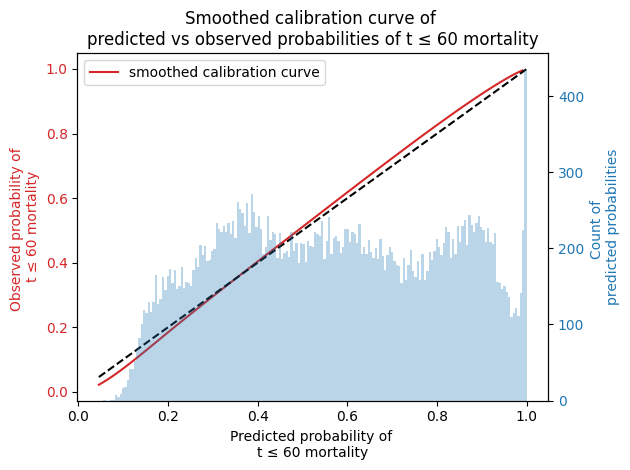

In [22]:
# Aplicando a calibração de probabilidade de sobrevivência para o modelo ajustado
survival_probability_calibration(
    cph,      # Modelo CoxPHFitter ajustado
    Xt,       # Banco de Dados
    t0 = 60   # Tempo alvo de sobrevivência para calibração
)

## <font color = 56A5EC>**Validação do Modelo**

### <font color = FFB90F>**Teste de Proporcionalidade (Schoenfeld)**

In [ ]:
# Teste de proporcionalidade, no tempo
ph = proportional_hazard_test(
    cph,                    # modelo ajustado
    Xt,                     # DataSet
    time_transform = 'rank' # rank dos tempos (default)
)

In [ ]:
# Exibição do sumário do teste (analisar se o p-value é menor que 0.05)
ph.print_summary()

In [ ]:
# Checagem das hipóteses do modelo e suas recomendações
cph.check_assumptions(
    Xt,                            # DataSet
    p_value_threshold = 0.05,      # Limiar para dar os alertas
    show_plots = True,             # Mostrar os gráficos
    columns = None                 # Restringe a algumas colunas (lista) ou usa todas as colunas do DataSet
)

### <font color = FFB90F>**Kaplan–Meier por Grupo (Log-rank-test)**

In [ ]:
# Função Exploratória
def km_by_group(df, time_col, event_col, group_col, title = None):
    """
    Descrição:
      Plota curvas de sobrevivência de Kaplan–Meier separadas por grupos (categorias)
      e executa o teste Log-rank global para verificar se as curvas diferem entre si.

    Parâmetros:
      df (pd.DataFrame):
        DataFrame contendo as colunas de tempo, evento e o grupo categórico.
      time_col (str):
        Nome da coluna com o tempo até evento/censura (ex.: 'time').
      event_col (str):
        Nome da coluna binária de evento (1 = evento/morte, 0 = censura).
      group_col (str):
        Nome da coluna categórica usada para separar os grupos.
      title (str | None):
        Título opcional do gráfico. Se None, cria um título padrão.

    Retorno:
      None (A função apenas plota e imprime resultados)
    """

    # ======================  #
    # ===TESTE LOG-RANK ===#
    # ======================  #

    # Cria um estimador de Kaplan-Meier
    kmf = KaplanMeierFitter()

    # Definição de uma nova figura para o gráfico
    plt.figure(figsize = (8, 6))

    # Divisão do DataFrame em subgrupos conforme cada categoria presente em group_col
    #     Ex.: se group_col = 'ECGRUP', teremos subgrupos para I, II, III, IV
    for level, sub in df.groupby(group_col):

        # Ajusta o Kaplan-Meier no subgrupo atual:
        kmf.fit(
            durations = sub[time_col],        # tempos observados
            event_observed = sub[event_col],  # indicador de evento (1) ou censura (0)
            label = f"{group_col} = {level}"    # nome que aparecerá na legenda do gráfico
        )

        # Plota a curva de sobrevivência estimada S(t) para o subgrupo atual
        kmf.plot_survival_function(ci_show = False) # remove o intervalo de confiança para deixar o gráfico mais limpo

    # Título do gráfico
    plt.title(title or f"Kaplan-Meier por {group_col}") # titúlo específico ou genérico

    # Nome dos eixos
    plt.xlabel("Tempo")
    plt.ylabel("S(t)")

    plt.grid(True)  # Quadriculado
    plt.show()      # Exibição gráfica

    # ======================== =====#
    # ===TESTE LOG-RANK GLOBAL ===#
    # ======================== =====#

    # Log-rank multivariado (global):
    #     H0: Avalia a hipótese nula: "todas as curvas de sobrevivência são iguais"
    #     H1: Se p < 0.05: há evidência estatística de diferença entre pelo menos dois grupos
    res = multivariate_logrank_test(
        event_durations = df[time_col], # coluna do tempo
        groups = df[group_col],         # grupos analisados
        event_observed = df[event_col]  # coluna do evento
    )

    # Imprime a estatística do teste
    #     qui-quadrado: Mede o quanto as curvas diferem
    #     p-valor: Significância estatística
    print(f"[KM] Log-rank global para {group_col}: chi2 = {res.test_statistic:.2f}, p = {res.p_value:.4g}\n")

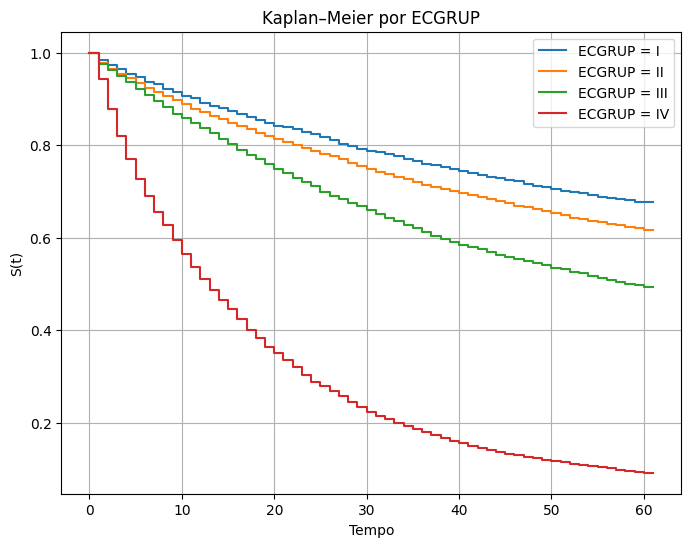

[KM] Log-rank global para ECGRUP: chi2 = 10907.81, p = 0



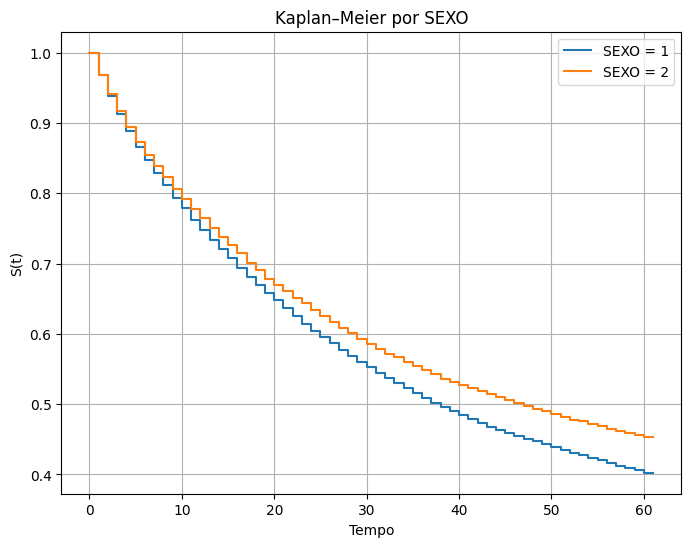

[KM] Log-rank global para SEXO: chi2 = 71.36, p = 2.982e-17



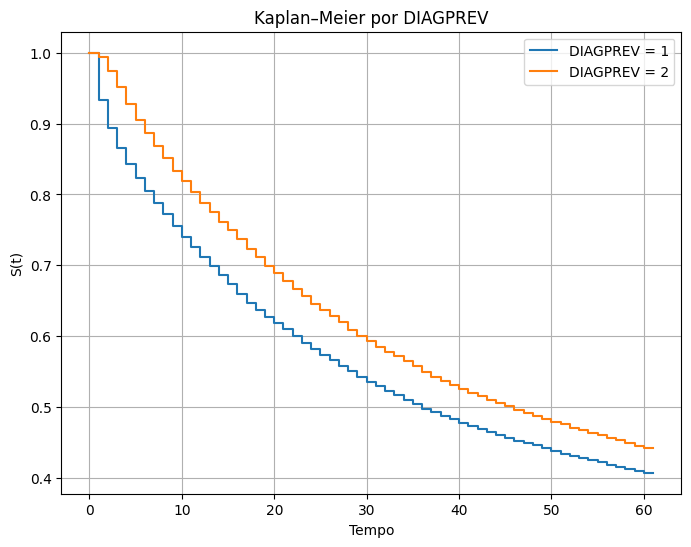

[KM] Log-rank global para DIAGPREV: chi2 = 113.79, p = 1.449e-26



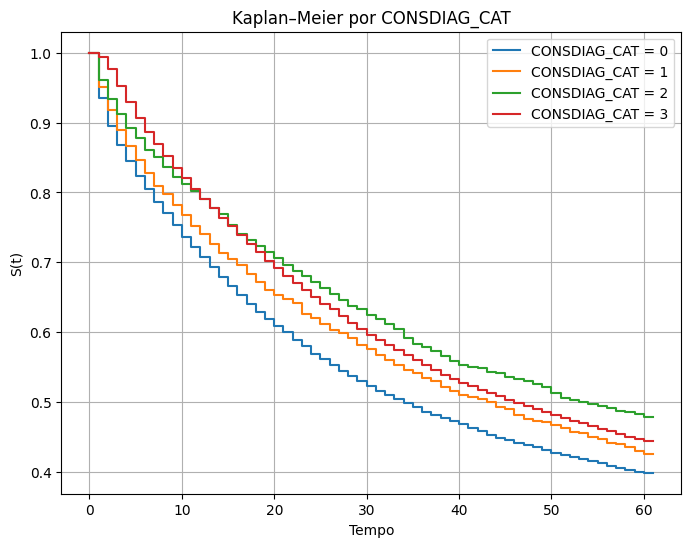

[KM] Log-rank global para CONSDIAG_CAT: chi2 = 166.72, p = 6.51e-36



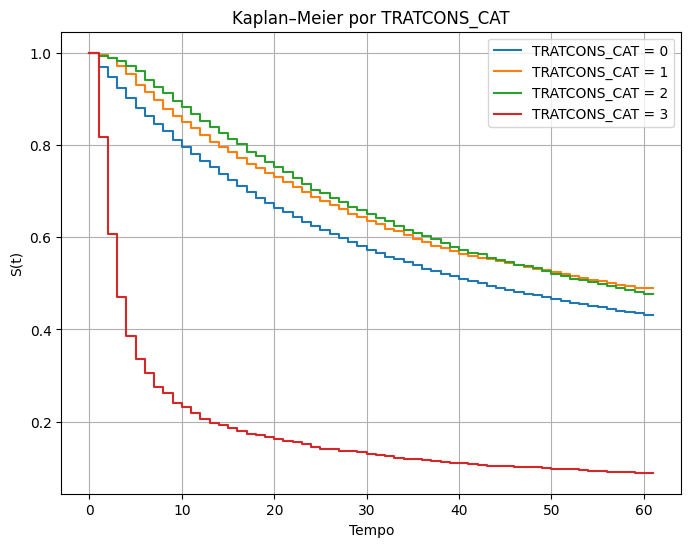

[KM] Log-rank global para TRATCONS_CAT: chi2 = 4311.62, p = 0



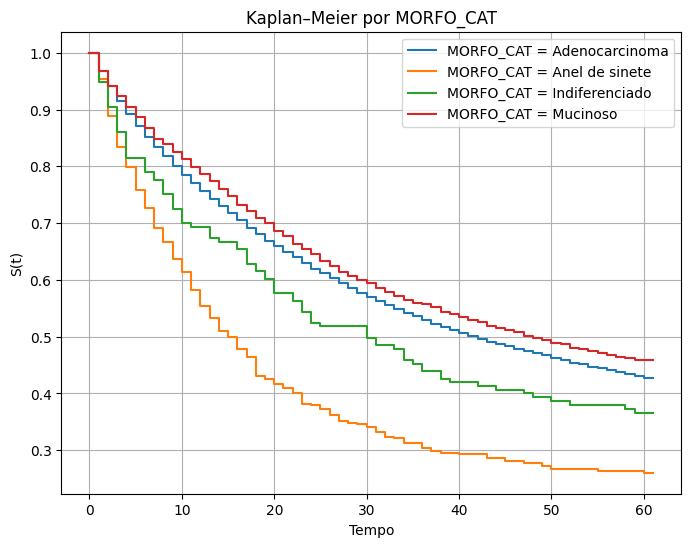

[KM] Log-rank global para MORFO_CAT: chi2 = 103.52, p = 2.718e-22



In [ ]:
# Lista de variáveis categóricas para análise exploratória
grupos_km = [
    'ECGRUP',          # Estadiamento clínico
    'SEXO',            # Sexo
    'DIAGPREV',        # Diagnóstico prévio
    'CONSDIAG_CAT',    # Tempo consulta–diagnóstico (categorizado)
    'TRATCONS_CAT',    # Tempo tratamento–consulta (categorizado)
    'MORFO_CAT'        # Morfologia tumoral
]

# Aplicação da análise Kaplan–Meier + Log-rank
for col in grupos_km:
    if col in df_colo.columns:
        km_by_group(
            df = df_colo,                     # DataFrame SEM codificação
            time_col = 'time',                # Tempo de sobrevivência (em meses)
            event_col = 'event',              # Evento (1 = óbito, 0 = censura)
            group_col = col,                  # Variável categórica analisada
            title = f"Kaplan–Meier por {col}" # Título
        )

### <font color = FFB90F>**Log(Log(X(t))))**

In [ ]:
# Função Gráfica
def loglog_plot_by_group(df, time_col, event_col, group_col, title = None):
    """
    Descrição:
      Plota o gráfico log(-log(S(t))) vs log(tempo) para cada nível (categoria) de `group_col`.
      Esse gráfico é um diagnóstico VISUAL da suposição de Proportional Hazards (PH).

      Interpretação:
        - Se as curvas dos grupos ficarem aproximadamente PARALELAS, isso sugere PH ok para esse fator.
        - Se cruzarem muito, abrirem/fecharem fortemente ou tiverem formatos muito diferentes,
          pode indicar violação de PH.

    Parâmetros:
      df (pd.DataFrame): DataFrame contendo as colunas de tempo, evento e a coluna categórica `group_col`.
      time_col (str): nome da coluna de tempo (ex.: "time").
      event_col (str): nome da coluna de evento (1 = evento, 0 = censura) (ex.: "event").
      group_col (str): nome da coluna categórica para separar em grupos (ex.: "ECGRUP").
      title (str | None): título opcional do gráfico.

    Retorno:
      None (A função apenas plota e imprime resultados)
    """

    # Cria o estimador de Kaplan-Meier (não-paramétrico)
    kmf = KaplanMeierFitter()

    # Abre uma figura nova para o gráfico
    plt.figure(figsize = (8, 6))

    # Agrupa o dataset por cada categoria do group_col
    for level, sub in df.groupby(group_col):
        kmf.fit(
            durations = sub[time_col],        # coluna de tempo
            event_observed = sub[event_col],  # coluna de evento
            label = f"{group_col} = {level}"    # variáveis analisadas
        )

        # Pega a curva de sobrevivência S(t) estimada pelo KM
        #   kmf.survival_function_ é um DataFrame com índice = tempos e 1 coluna (a curva)
        sf = kmf.survival_function_.iloc[:, 0]

        # Proteções numéricas:
        # - S(t) pode chegar a 0 em tempos tardios -> log(0) é inválido
        # - tempo pode ter 0 -> log(0) é inválido
        eps = 1e-10
        s = sf.clip(lower = eps)                          # evita S(t) = 0
        t = sf.index.to_numpy().clip(min = eps)           # evita tempo = 0

        # Transformações do gráfico:
        # y = log(-log(S(t)))
        # x = log(t)
        y = np.log(-np.log(s.to_numpy()))
        x = np.log(t)

        # Plota a curva transformada para esse grupo
        plt.plot(x, y, label = f"{group_col} = {level}")

    # Título específico ou título padrão
    plt.title(title or f"log(-log(S(t))) vs log(tempo) por {group_col}")

    # Eixos
    plt.xlabel("log(tempo)")
    plt.ylabel("log(-log(S(t)))")

    plt.legend()    # Legenda
    plt.grid(True)  # Quadriculado
    plt.show()      # Exibição


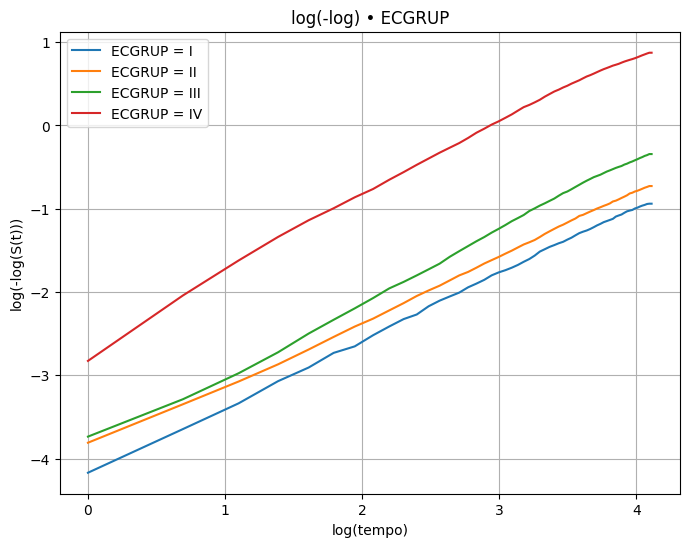

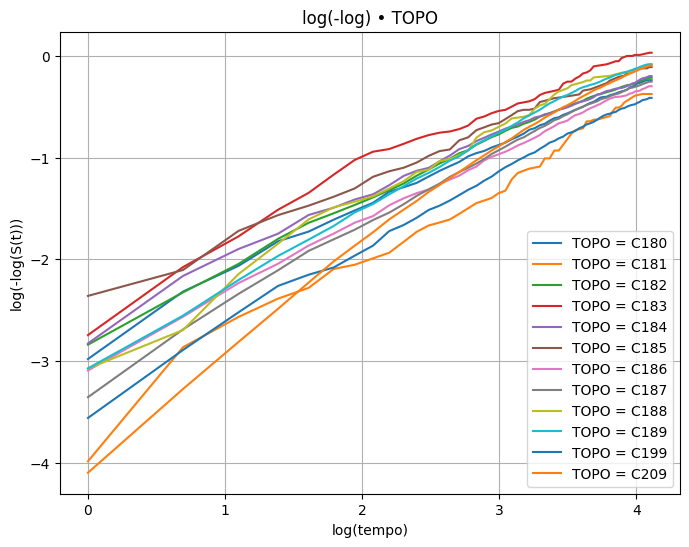

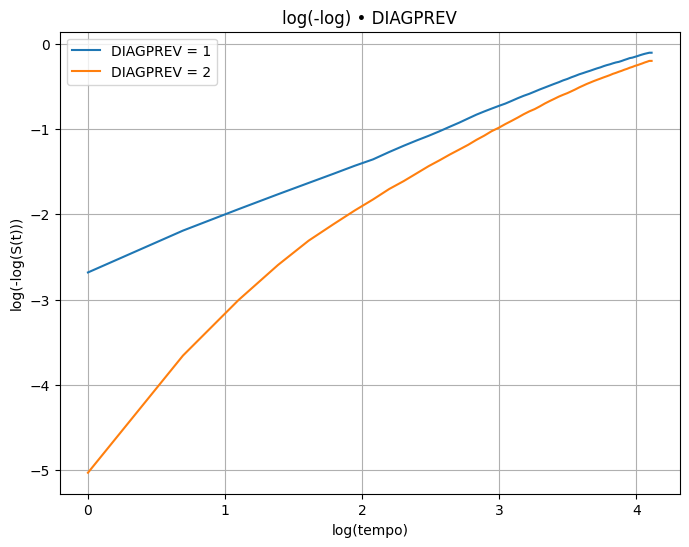

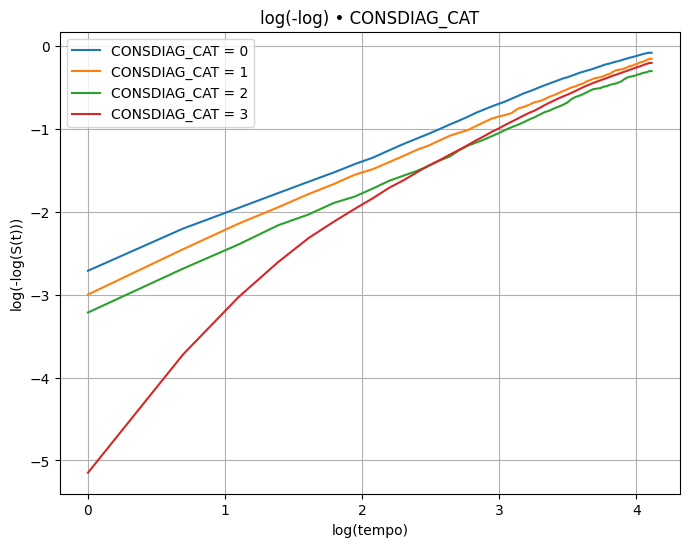

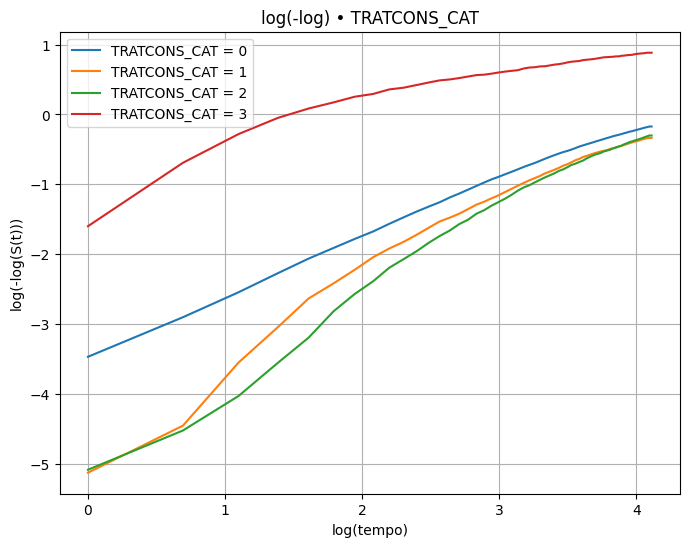

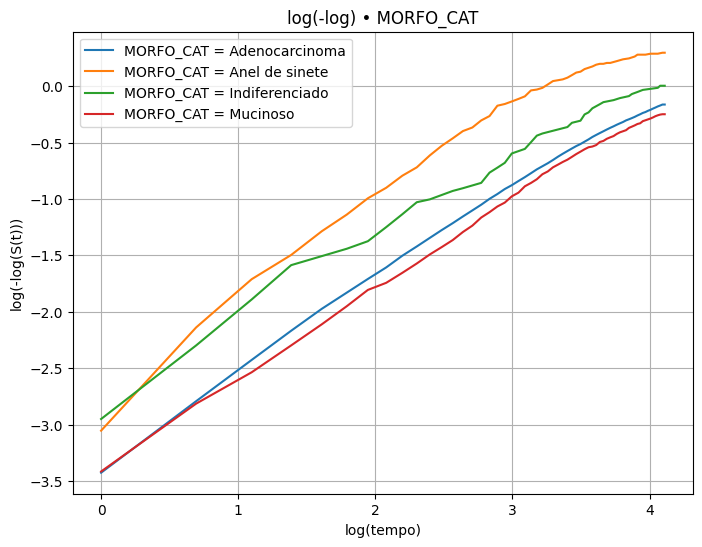

In [ ]:
# Lista de variáveis categóricas para análise exploratória ???
cats_to_check = [
    'ECGRUP',          # Estadiamento clínico
    'TOPO',            # Topografia
    'DIAGPREV',        # Diagnóstico prévio
    'CONSDIAG_CAT',    # Tempo consulta–diagnóstico (categorizado)
    'TRATCONS_CAT',    # Tempo tratamento–consulta (categorizado)
    'MORFO_CAT'        # Morfologia tumoral
]

for col in cats_to_check:
    if col in df_colo.columns:
        loglog_plot_by_group(
            df = df_colo,                     # DataFrame SEM codificação
            time_col = 'time',                # Tempo de sobrevivência (em meses)
            event_col = 'event',              # Evento (1 = óbito, 0 = censura)
            group_col = col,                  # Variável categórica analisada
            title = f"log(-log) • {col}"      # Título
        )

### <font color = FFB90F>**Resíduos de Martingale**

In [ ]:
def martingale(cph, df, cont_col, time_col = 'time', event_col = 'event'):
    """
    Descrição:
      Avalia se a relação entre uma variável contínua (`cont_col`) e o log-hazard
      é aproximadamente linear, como assumido pelo modelo de Cox padrão.

      O diagnóstico é feito por meio dos resíduos de Martingale:
        - Se os resíduos estiverem distribuídos aleatoriamente ao redor de 0,
          a suposição de linearidade é plausível.
        - Se houver padrão curvo (U, ∩, tendência crescente/decrescente),
          isso sugere que a variável NÃO entra de forma linear no log-hazard.

    Parâmetros:
      cph : lifelines.CoxPHFitter
        Modelo Cox já ajustado.
      df : pandas.DataFrame
        DataFrame usado no fit (ou equivalente), contendo `cont_col`, `time` e `event`.
      cont_col : str
        Nome da variável contínua a ser avaliada (ex.: "IDADE").
      time_col : str
        Nome da coluna de tempo (def = ult = "time").
      event_col : str
        Nome da coluna de evento (d = fault = "event").

    Retorno:
        (Apenas exibe o gráfico diagnóstico)
    """

    # Calcula os resíduos de Martingale para cada observação (eles medem a diferença entre eventos observados e esperados)
    res_mart = cph.compute_residuals(df, kind='martingale')

    # Cria a figura
    plt.figure(figsize = (7, 5))

    # Scatter plot
    plt.scatter(
        x = df[cont_col],         # eixo x: variável co = tínua
        y = res_mart.iloc[:, 0],  # pega a única coluna de resíduos,  # eixo y: resíduos de Ma=tingale
        s = 5,                  # tamanho do ma=cador
        alpha = 0.3             # transparência
    )

    # plt.scatter(
    #     df[cont_col],
    #     res_mart[event_col],
    #     s=5,
    #     alpha=0.3
    # )

    # Ajuste de uma curva suavizada (poli = ômio de grau 2)
    z = np.polyfit(df[cont_col], res_mart[event_col], 2)
    xp = np.linspace(df[cont_col].min(), df[cont_col].max(), 200)
    plt.plot(xp, np.polyval(z, xp))

    # Linha horizontal em y = 0 (referência)
    plt.axhline(0, ls = '--', lw = 1)

    # Título e rótulos
    plt.title(f"Resíduo de Martingale vs {cont_col}")
    plt.xlabel(cont_col)
    plt.ylabel("Martingale residual")

    # Quadriculado
    plt.grid(True)

    # Exibição
    plt.show()

/usr/local/lib/python3.12/dist-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


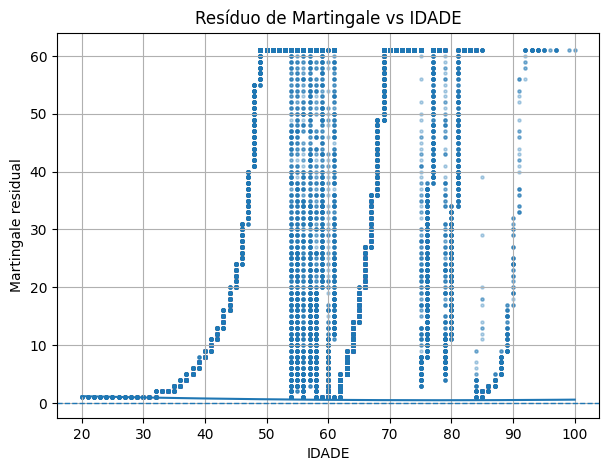

In [ ]:
# Aplicação do Teste
martingale(
    cph = cph,          # Modelo de Cox ajustado
    df = Xt,            # DataSet
    cont_col = "IDADE"  # Coluna contínua
)

## <font color = 56A5EC>**C-Índex**

In [ ]:
# Cálculo do índice de concordância do modelo ajustado
c_index = cph.score(Xt, scoring_method = 'concordance_index')
print(f'Concordance Index: {c_index}')

/usr/local/lib/python3.12/dist-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


Concordance Index: 0.6983249347892989


## <font color = 56A5EC>**P-Values**





### <font color = FFB90F>**Seleção do DataFrame com as variáveis significativas**

In [ ]:
def selecionar_variaveis_significativas(cph_model, X, p_val_threshold=0.05, strata_cols=None):
    """
    Descrição:
      Seleciona as variáveis significativas do modelo de Cox com base no p-value.

    Parâmetros:
      cph_model : lifelines.CoxPHFitter
          Modelo Cox já ajustado.

      X : pd.DataFrame
          DataFrame usado no ajuste do modelo.

      p_val_threshold : float, default=0.05
          Limiar de significância estatística.

      strata_cols : list, default=None
          Lista de colunas usadas como strata no modelo.

    Retorno:
      X_sig : pd.DataFrame
          DataFrame contendo:
          - variáveis significativas;
          - colunas de strata;
          - colunas 'time' e 'event'.
    """

    # Se não houver strata, usa lista vazia
    if strata_cols is None:
        strata_cols = []

    # Seleciona os nomes das variáveis com p-value menor que o limiar
    sig_vars = cph_model.summary.loc[cph_model.summary["p"] < p_val_threshold].index.tolist()

    # Monta a lista final de colunas que serão mantidas
    keep_cols = sig_vars + strata_cols + ["time", "event"]

    # Remove duplicatas, se houver
    keep_cols = list(dict.fromkeys(keep_cols))

    # Retorna o DataFrame reduzido
    X_sig = X[keep_cols].copy()

    return X_sig

In [ ]:
# Filtrar as variáveis significativas com p-value < 0.05
Xt_significativos = selecionar_variaveis_significativas(
    cph_model=cph,
    X=Xt,
    p_val_threshold=0.05,
    strata_cols=strata_cols
)

In [ ]:
# Exibição do novo DataFrame
display(Xt_significativos)
print(Xt_significativos.shape)

,INSTITU,ESCOLARI,IDADE,SEXO,CATEATEND,ECGRUP,ANODIAG,DIAGTRAT_CAT,TOPO_C181,TOPO_C183,...,TOPO_C199,TOPO_C209,MORFO_CAT_Anel de sinete,MORFO_CAT_Indiferenciado,MORFO_CAT_Mucinoso,DIAGPREV,TRATCONS_CAT,CONSDIAG_CAT,time,event
0,9326,2,20,1,2,3.0,2019,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1,2,2,33,1
1,12,4,20,2,9,3.0,2008,0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,2,0,3,4,1
2,16624,5,20,2,2,3.0,2014,2,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2,2,3,26,1
3,8672,4,20,2,2,3.0,2015,0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1,1,0,3,1
4,20737,4,20,2,2,2.0,2016,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2,0,3,61,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32659,612374,9,97,2,2,2.0,2016,0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,2,0,3,9,1
32660,612374,9,99,2,2,3.0,2013,2,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,2,1,3,19,1
32661,20621,2,99,1,2,0.0,2016,0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,2,0,3,17,1
32662,208066,2,100,1,2,1.0,2007,3,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1,3,1,2,1


(32664, 22)


In [ ]:
# Lista de colunas atualizadas
print("Colunas do modelo reduzido:")
display(Xt_significativos.columns)

Colunas do modelo reduzido:


Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'CATEATEND', 'ECGRUP',
       'ANODIAG', 'DIAGTRAT_CAT', 'TOPO_C181', 'TOPO_C183', 'TOPO_C184',
       'TOPO_C185', 'TOPO_C199', 'TOPO_C209', 'MORFO_CAT_Anel de sinete',
       'MORFO_CAT_Indiferenciado', 'MORFO_CAT_Mucinoso', 'DIAGPREV',
       'TRATCONS_CAT', 'CONSDIAG_CAT', 'time', 'event'],
      dtype='object')

### <font color = FFB90F>**FIT do modelo significativo**

In [ ]:
# FIT do Modelo significativo
cph_significativo = CoxPHFitter(penalizer = 0.01)

cph_significativo.fit(
    Xt_significativos,
    duration_col = "time",
    event_col = "event",
    strata = strata_cols
)

<lifelines.CoxPHFitter: fitted with 32664 total observations, 14524 right-censored observations>

In [ ]:
# Exibir o sumário do modelo ajustado
cph_significativo.print_summary()

model,lifelines.CoxPHFitter
duration col,'time'
event col,'event'
penalizer,0.01
l1 ratio,0.0
strata,"[DIAGPREV, TRATCONS_CAT, CONSDIAG_CAT]"
baseline estimation,breslow
number of observations,32664
number of events observed,18140
partial log-likelihood,-139237.53
time fit was run,2026-03-09 16:46:14 UTC


### <font color = FFB90F>**Comparação**

In [ ]:
# Comparação dos C-index
c_index_original = cph.score(Xt, scoring_method = "concordance_index")
c_index_significativo = cph_significativo.score(Xt_significativos, scoring_method = "concordance_index")

print(f"C-index do modelo original: {c_index_original:.4f}")
print(f"C-index do modelo significativo: {c_index_significativo:.4f}")

/usr/local/lib/python3.12/dist-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
/usr/local/lib/python3.12/dist-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


C-index do modelo original: 0.6983
C-index do modelo significativo: 0.6982


In [ ]:
# Comparação das colunas
colunas_originais = Xt.columns.drop(["time", "event"])
colunas_significativas = Xt_significativos.columns.drop(["time", "event"])
colunas_removidas = colunas_originais.difference(colunas_significativas)

print("Colunas removidas após seleção por p-value:")
display(colunas_removidas)

Colunas removidas após seleção por p-value:


Index(['HABILIT', 'TOPO_C182', 'TOPO_C186', 'TOPO_C187', 'TOPO_C188',
       'TOPO_C189', 'nDRS'],
      dtype='object')

### <font color = FFB90F>**Gráfico**

O gráfico dos coeficientes do modelo de Cox apresenta as estimativas dos efeitos das covariáveis na escala log(HR), acompanhadas de seus intervalos de confiança de 95%. Covariáveis com coeficientes positivos indicam aumento do risco do evento, enquanto coeficientes negativos sugerem redução do risco em relação à categoria de referência. A distância em relação a zero reflete a magnitude do efeito, e intervalos que cruzam zero indicam menor evidência de associação estatisticamente significativa.

- <font color = #888B90>**Eixo X:**</font>
Coeficiente na escala log(HR)

- <font color = #FF7F50>**Eixo Y:**</font>
Intervalo de confiança de 95%

- <font color = #9E7BFF>**Linha vertical em 0:**</font>
Ausência de efeito

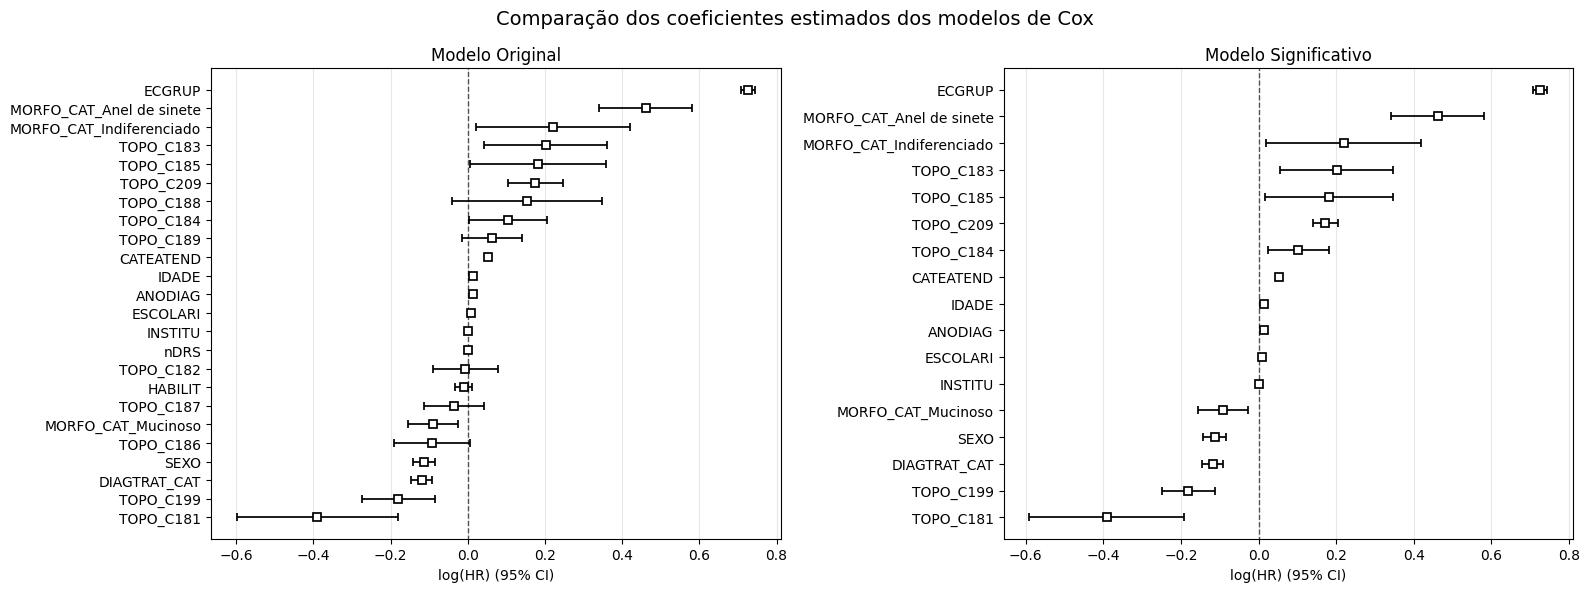

In [ ]:
# Gráficos dos coeficientes estimados do modelo de Cox
fig, axes = plt.subplots(1, 2, figsize = (16, 6))

# Modelo original
plt.sca(axes[0])
cph.plot()
axes[0].set_title("Modelo Original")
axes[0].grid(True, axis = "x", alpha = 0.3)

# Modelo significativo
plt.sca(axes[1])
cph_significativo.plot()
axes[1].set_title("Modelo Significativo")
axes[1].grid(True, axis = "x", alpha = 0.3)

plt.suptitle("Comparação dos coeficientes estimados dos modelos de Cox", fontsize = 14)
plt.tight_layout()
plt.show()

## <font color = 56A5EC>**Predição**

### <font color = FFB90F>**Modelo Original**

In [ ]:
# Predição do tempo de sobrevivência esperado para o modelo original
y_pred_tempo_original = cph.predict_expectation(Xt)

# DataFrame com valores reais e previstos
df_pred_tempo_original = pd.DataFrame({
    "Tempo de Sobrevida Real": Xt["time"],
    "Tempo de Sobrevida Previsto (Original)": y_pred_tempo_original
})

# Exibição
display(df_pred_tempo_original.head())

,Tempo de Sobrevida Real,Tempo de Sobrevida Previsto (Original)
0,33,35.515229
1,4,30.381123
2,26,42.893776
3,3,31.974066
4,61,47.775317


In [ ]:
# Estatísticas básicas das previsões
print(f"Valor mínimo do tempo previsto (Original): {y_pred_tempo_original.min():.4f}")
print(f"Valor máximo do tempo previsto (Original): {y_pred_tempo_original.max():.4f}")

Valor mínimo do tempo previsto (Original): 0.8349
Valor máximo do tempo previsto (Original): 57.9661


In [ ]:
# Diferença entre tempo real e previsto
diferenca_tempo_original = Xt["time"] - y_pred_tempo_original

print(f"Valor mínimo da diferença real - previsto (Original): {diferenca_tempo_original.min():.4f}")
print(f"Valor máximo da diferença real - previsto (Original): {diferenca_tempo_original.max():.4f}")

Valor mínimo da diferença real - previsto (Original): -55.2465
Valor máximo da diferença real - previsto (Original): 59.0403


### <font color = FFB90F> **Modelo Significativo**

In [ ]:
# Predição do tempo de sobrevivência esperado para o modelo significativo
y_pred_tempo_significativo = cph_significativo.predict_expectation(Xt_significativos)

# DataFrame com valores reais e previstos
df_pred_tempo_significativo = pd.DataFrame({
    "Tempo de Sobrevida Real": Xt_significativos["time"],
    "Tempo de Sobrevida Previsto (Significativo)": y_pred_tempo_significativo
})

# Exibição
display(df_pred_tempo_significativo.head())

,Tempo de Sobrevida Real,Tempo de Sobrevida Previsto (Significativo)
0,33,35.404937
1,4,30.213924
2,26,43.742190
3,3,32.062728
4,61,47.433624


In [ ]:
# Estatísticas básicas das previsões
print(f"Valor mínimo do tempo previsto (Significativo): {y_pred_tempo_significativo.min():.4f}")
print(f"Valor máximo do tempo previsto (Significativo): {y_pred_tempo_significativo.max():.4f}")

Valor mínimo do tempo previsto (Significativo): 0.8275
Valor máximo do tempo previsto (Significativo): 57.9406


In [ ]:
# Diferença entre tempo real e previsto
diferenca_tempo_significativo = Xt_significativos["time"] - y_pred_tempo_significativo

print(f"Valor mínimo da diferença real - previsto (Significativo): {diferenca_tempo_significativo.min():.4f}")
print(f"Valor máximo da diferença real - previsto (Significativo): {diferenca_tempo_significativo.max():.4f}")

Valor mínimo da diferença real - previsto (Significativo): -55.2218
Valor máximo da diferença real - previsto (Significativo): 59.1474


### <font color = FFB90F> **Comparação/Pacientes específicos (Gráficos)**

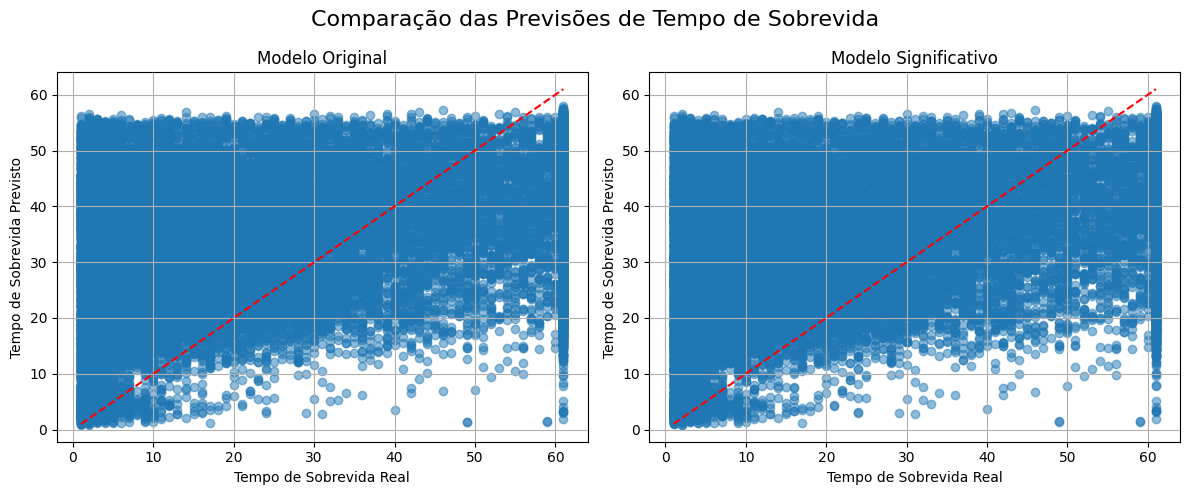

In [ ]:
# Figura com comparação entre valores reais e previstos
plt.figure(figsize = (12, 5))

# Modelo original
plt.subplot(1, 2, 1)
plt.scatter(
    df_pred_tempo_original["Tempo de Sobrevida Real"],
    df_pred_tempo_original["Tempo de Sobrevida Previsto (Original)"],
    alpha = 0.5
)
plt.plot(
    [df_pred_tempo_original["Tempo de Sobrevida Real"].min(), df_pred_tempo_original["Tempo de Sobrevida Real"].max()],
    [df_pred_tempo_original["Tempo de Sobrevida Real"].min(), df_pred_tempo_original["Tempo de Sobrevida Real"].max()],
    "r--"
)
plt.xlabel("Tempo de Sobrevida Real")
plt.ylabel("Tempo de Sobrevida Previsto")
plt.title("Modelo Original")
plt.grid(True)

# Modelo significativo
plt.subplot(1, 2, 2)
plt.scatter(
    df_pred_tempo_significativo["Tempo de Sobrevida Real"],
    df_pred_tempo_significativo["Tempo de Sobrevida Previsto (Significativo)"],
    alpha = 0.5
)
plt.plot(
    [df_pred_tempo_significativo["Tempo de Sobrevida Real"].min(), df_pred_tempo_significativo["Tempo de Sobrevida Real"].max()],
    [df_pred_tempo_significativo["Tempo de Sobrevida Real"].min(), df_pred_tempo_significativo["Tempo de Sobrevida Real"].max()],
    "r--"
)
plt.xlabel("Tempo de Sobrevida Real")
plt.ylabel("Tempo de Sobrevida Previsto")
plt.title("Modelo Significativo")
plt.grid(True)

plt.suptitle("Comparação das Previsões de Tempo de Sobrevida", fontsize = 16)
plt.tight_layout()
plt.show()

## <font color = 56A5EC>**Métricas de Erro**

In [ ]:
def ibs(cph_model, X, time_col="time", event_col="event", t0=60):
    """
    Descrição:
      Calcula o IBS (Integrated Brier Score) para um modelo Cox ajustado.

    Parâmetros:
      cph_model : lifelines.CoxPHFitter
          Modelo Cox já ajustado.

      X : pd.DataFrame
          DataFrame com as covariáveis e as colunas de tempo e evento.

      time_col : str, default="time"
          Nome da coluna de tempo.

      event_col : str, default="event"
          Nome da coluna de evento.

      t0 : int, default=60
          Horizonte máximo de tempo para o cálculo do IBS.

    Retorno:
      float
          Valor do IBS.
    """

    # Estrutura de sobrevivência no formato do scikit-survival
    y = Surv.from_dataframe(event_col, time_col, X)

    # Grade de tempos até o horizonte máximo
    times = np.arange(1, min(t0, int(X[time_col].max())) + 1)

    # Curvas de sobrevivência previstas pelo modelo
    sf = cph_model.predict_survival_function(X)

    # Ajusta as curvas para a grade temporal escolhida
    sf = sf.reindex(times, method="pad").bfill()

    # Converte para o formato exigido pelo integrated_brier_score
    surv_matrix = sf.T.values

    # Calcula o IBS
    score = integrated_brier_score(y, y, surv_matrix, times)

    return float(score)

In [ ]:
def c_index_ipcw_cox(cph_model, X, time_col = "time", event_col = "event", tau = None):
    """
    Descrição:
      Calcula o C-Index IPCW para um modelo Cox ajustado.

      O IPCW (Inverse Probability of Censoring Weighting) ajusta o índice
      de concordância para a presença de censura, tornando a avaliação
      mais apropriada para dados de sobrevivência.

    Parâmetros:
      cph_model : lifelines.CoxPHFitter
          Modelo Cox já ajustado.

      X : pd.DataFrame
          DataFrame com as covariáveis e as colunas de tempo e evento.

      time_col : str, default="time"
          Nome da coluna de tempo.

      event_col : str, default="event"
          Nome da coluna de evento.

      tau : float or None, default=None
          Horizonte máximo considerado no cálculo.
          Se None, usa o maior tempo observado no conjunto.

    Retorno:
      float
          Valor do C-Index IPCW.
    """

    # Estrutura de sobrevivência no formato do scikit-survival
    y = Surv.from_dataframe(event_col, time_col, X)

    # Escore de risco previsto pelo modelo
    risk_scores = cph_model.predict_partial_hazard(X).values.ravel()

    # Horizonte máximo de tempo para o cálculo
    if tau is None:
        tau = X[time_col].max()

    # Calcula o C-Index IPCW
    c_ipcw = concordance_index_ipcw(y, y, risk_scores, tau = tau)[0]

    return float(c_ipcw)

In [ ]:
def cox_metrics_table(
    model1, X1,
    model2, X2,
    name1 = "Modelo Original",
    name2 = "Modelo Significativo",
    time_col = "time",
    event_col = "event",
    t0 = 60
):
    """
    Descrição:
      Calcula e compara métricas entre dois modelos de Cox.

    Métricas principais:
      - C-Index
      - C-Index IPCW
      - IBS

    Métricas complementares:
      - MSE
      - RMSE
      - MAE

    Parâmetros:
      model1, model2 : lifelines.CoxPHFitter
          Modelos Cox ajustados.

      X1, X2 : pd.DataFrame
          DataFrames usados em cada modelo.

      name1, name2 : str
          Nomes que aparecerão na tabela.

      time_col : str, default="time"
          Nome da coluna de tempo.

      event_col : str, default="event"
          Nome da coluna de evento.

      t0 : int, default=60
          Horizonte máximo para o cálculo do IBS e do C-Index IPCW.

    Retorno:
      pd.DataFrame
          Tabela comparativa das métricas.
    """

    # Previsões do tempo esperado de sobrevivência
    pred1 = model1.predict_expectation(X1)
    pred2 = model2.predict_expectation(X2)

    # Métricas do modelo 1
    m1 = {
        "C-Index": float(model1.score(X1, scoring_method = "concordance_index")),
        "C-Index IPCW": c_index_ipcw_cox(model1, X1, time_col = time_col, event_col = event_col, tau = t0),
        "IBS": ibs(model1, X1, time_col = time_col, event_col = event_col, t0 = t0),
        "MSE": float(mean_squared_error(X1[time_col], pred1)),
        "RMSE": float(np.sqrt(mean_squared_error(X1[time_col], pred1))),
        "MAE": float(mean_absolute_error(X1[time_col], pred1))
    }

    # Métricas do modelo 2
    m2 = {
        "C-Index": float(model2.score(X2, scoring_method = "concordance_index")),
        "C-Index IPCW": c_index_ipcw_cox(model2, X2, time_col = time_col, event_col = event_col, tau = t0),
        "IBS": ibs(model2, X2, time_col = time_col, event_col = event_col, t0 = t0),
        "MSE": float(mean_squared_error(X2[time_col], pred2)),
        "RMSE": float(np.sqrt(mean_squared_error(X2[time_col], pred2))),
        "MAE": float(mean_absolute_error(X2[time_col], pred2))
    }

    # Tabela final
    df_metrics = pd.DataFrame({
        name1: m1,
        name2: m2
    })

    df_metrics.index.name = "Métrica"

    display(df_metrics)
    return df_metrics

In [ ]:
df_comparacao = cox_metrics_table(
    model1 = cph,
    X1 = Xt,
    model2 = cph_significativo,
    X2 = Xt_significativos,
    name1 = "Modelo Original",
    name2 = "Modelo Significativo",
    t0 = 60
)

/usr/local/lib/python3.12/dist-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
/usr/local/lib/python3.12/dist-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


,Modelo Original,Modelo Significativo
Métrica,,
C-Index,0.698325,0.698248
C-Index IPCW,0.697761,0.697671
IBS,0.264548,0.264471
MSE,410.694104,411.146160
RMSE,20.265589,20.276739
MAE,17.112161,17.123509


## <font color = 56A5EC>**Gráficos**

### <font color = FFB90F>**Modelo Significativo: Tempo Real vs Previsto**


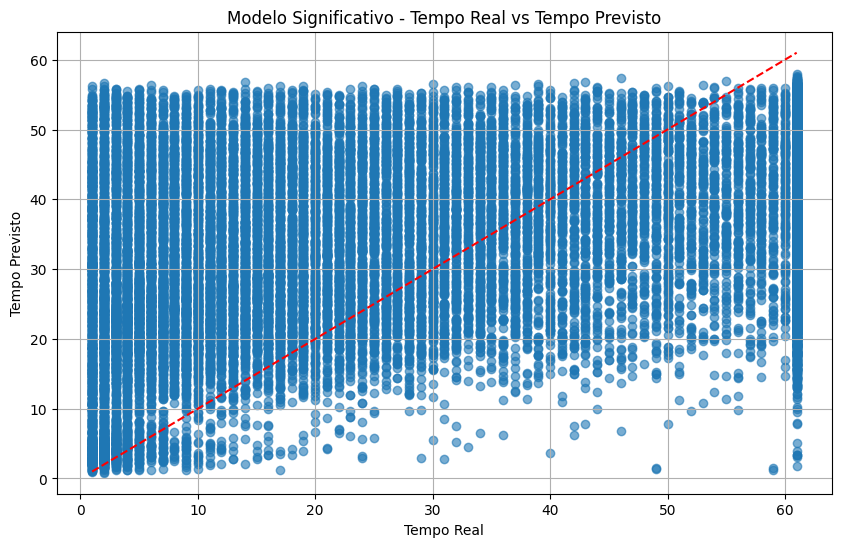

In [ ]:
plt.figure(figsize = (10, 6))
plt.scatter(Xt_significativos["time"], y_pred_tempo_significativo, alpha = 0.6)
plt.plot(
    [Xt_significativos["time"].min(), Xt_significativos["time"].max()],
    [Xt_significativos["time"].min(), Xt_significativos["time"].max()],
    color = "red",
    linestyle = "--"
)
plt.xlabel("Tempo Real")
plt.ylabel("Tempo Previsto")
plt.title("Modelo Significativo - Tempo Real vs Tempo Previsto")
plt.grid(True)
plt.show()

### <font color = FFB90F>**Distribuição dos Resíduos**

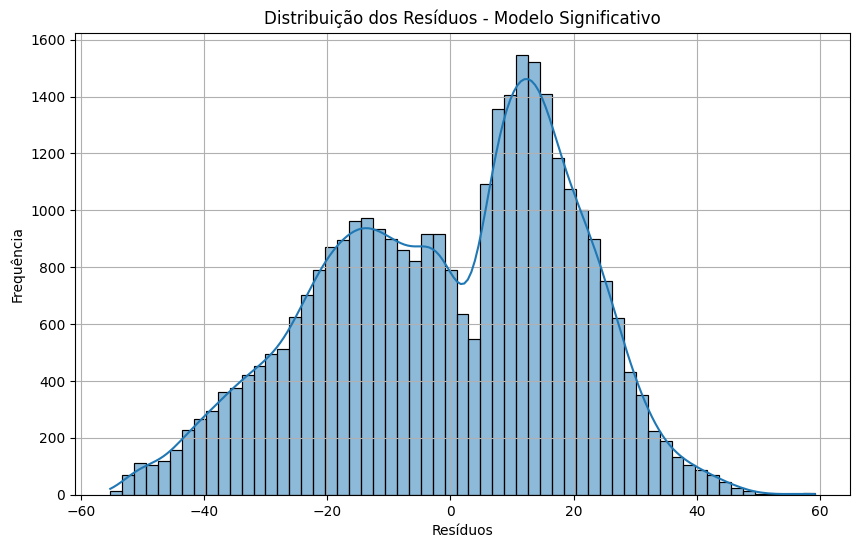

In [ ]:
residuos_significativo = Xt_significativos["time"] - y_pred_tempo_significativo

plt.figure(figsize = (10, 6))
sns.histplot(residuos_significativo, kde = True)
plt.xlabel("Resíduos")
plt.ylabel("Frequência")
plt.title("Distribuição dos Resíduos - Modelo Significativo")
plt.grid(True)
plt.show()

### <font color = FFB90F>**Curva de Kaplan-Meier Geral**

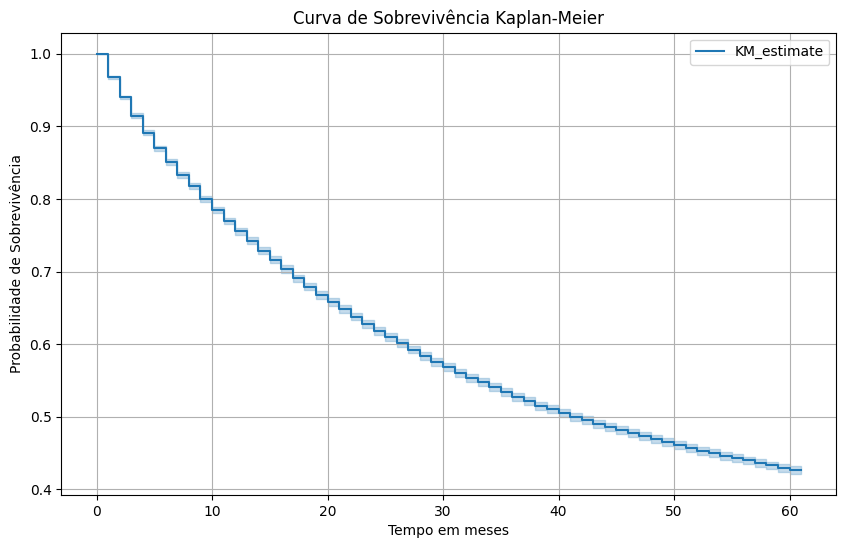

In [ ]:
kmf = KaplanMeierFitter()
kmf.fit(Xt["time"], Xt["event"])

plt.figure(figsize = (10, 6))
kmf.plot_survival_function()
plt.title("Curva de Sobrevivência Kaplan-Meier")
plt.xlabel("Tempo em meses")
plt.ylabel("Probabilidade de Sobrevivência")
plt.grid(True)
plt.show()

### <font color = FFB90F>**Distribuição do Tempo de Sobrevida**

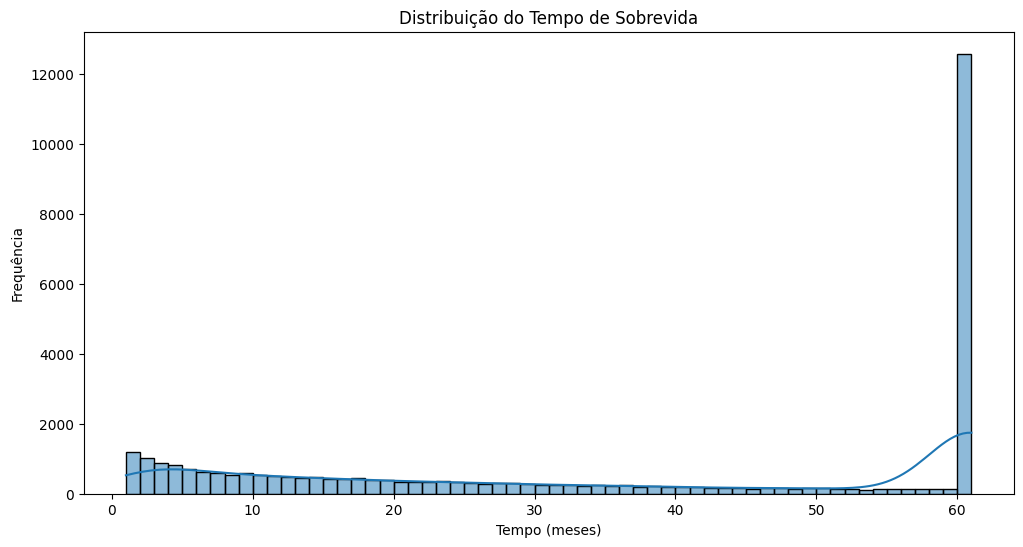

In [ ]:
plt.figure(figsize = (12, 6))
sns.histplot(Xt["time"], bins = 60, edgecolor = "k", kde = True)
plt.title("Distribuição do Tempo de Sobrevida")
plt.xlabel("Tempo (meses)")
plt.ylabel("Frequência")
plt.show()